In [60]:
#!pip install yfinance

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import bs4 as bs
import requests
import seaborn as sns

In [3]:
soup

NameError: name 'soup' is not defined

In [2]:
# Pegando todos os tickers do S&P500
resp = requests.get('http://en.wikipedia.org/wiki/List_of_S%26P_500_companies')
soup = bs.BeautifulSoup(resp.text, 'lxml')
table = soup.find('table', {'class': 'wikitable sortable sticky-header'})
tickers = []
for row in table.findAll('tr')[1:]:
    ticker = row.findAll('td')[0].text
    tickers.append(ticker)

tickers = [s.replace('\n', '') for s in tickers]
tickers

['MMM',
 'AOS',
 'ABT',
 'ABBV',
 'ACN',
 'ADBE',
 'AMD',
 'AES',
 'AFL',
 'A',
 'APD',
 'ABNB',
 'AKAM',
 'ALB',
 'ARE',
 'ALGN',
 'ALLE',
 'LNT',
 'ALL',
 'GOOGL',
 'GOOG',
 'MO',
 'AMZN',
 'AMCR',
 'AEE',
 'AEP',
 'AXP',
 'AIG',
 'AMT',
 'AWK',
 'AMP',
 'AME',
 'AMGN',
 'APH',
 'ADI',
 'AON',
 'APA',
 'APO',
 'AAPL',
 'AMAT',
 'APTV',
 'ACGL',
 'ADM',
 'ANET',
 'AJG',
 'AIZ',
 'T',
 'ATO',
 'ADSK',
 'ADP',
 'AZO',
 'AVB',
 'AVY',
 'AXON',
 'BKR',
 'BALL',
 'BAC',
 'BAX',
 'BDX',
 'BRK.B',
 'BBY',
 'TECH',
 'BIIB',
 'BLK',
 'BX',
 'XYZ',
 'BK',
 'BA',
 'BKNG',
 'BSX',
 'BMY',
 'AVGO',
 'BR',
 'BRO',
 'BF.B',
 'BLDR',
 'BG',
 'BXP',
 'CHRW',
 'CDNS',
 'CZR',
 'CPT',
 'CPB',
 'COF',
 'CAH',
 'KMX',
 'CCL',
 'CARR',
 'CAT',
 'CBOE',
 'CBRE',
 'CDW',
 'COR',
 'CNC',
 'CNP',
 'CF',
 'CRL',
 'SCHW',
 'CHTR',
 'CVX',
 'CMG',
 'CB',
 'CHD',
 'CI',
 'CINF',
 'CTAS',
 'CSCO',
 'C',
 'CFG',
 'CLX',
 'CME',
 'CMS',
 'KO',
 'CTSH',
 'COIN',
 'CL',
 'CMCSA',
 'CAG',
 'COP',
 'ED',
 'STZ',
 'CEG',


In [4]:
len(tickers)

503

In [7]:
# Baixar dados históricos

# substituir 'BRK.B' por 'BRK-B' )em todos os casos)
def download_one_ticker(ticker, start, end, max_retries=3, delay=5):
    for attempt in range(max_retries):
        try:
            sanitized = ticker.replace(".", "-")
            df = yf.download(sanitized, start=start, end=end, auto_adjust=True,
                             progress=False, threads=False, timeout=30)
            
            if not df.empty:
                return df["Close"]
            else:
                return None
                
        except Exception as e:
            err_msg = str(e)
            print(err_msg)
            
            # Outros erros → re-tenta
            time.sleep(delay)

    return None

start_date_full = "1997-01-02"
start_date = "2006-01-02"
end_date = "2007-12-31"

dict_data = {}
dict_data_full = {}
data_fail = []
data_full_fail = []

for ticker in tickers:
    data_ticker = download_one_ticker(ticker, start_date, end_date)
    print(ticker)
    if data_ticker is not None:
        dict_data[ticker] = data_ticker
    else:
        data_fail.append(ticker)

    data_ticker_full = download_one_ticker(ticker, start_date_full, end_date)
    if data_ticker_full is not None:
        dict_data_full[ticker] = data_ticker_full
    else:
        data_full_fail.append(ticker)

# Construir DataFrames
data = pd.concat(dict_data.values(), axis=1)
data.columns = dict_data.keys()

data_full = pd.concat(dict_data_full.values(), axis=1)
data_full.columns = dict_data_full.keys()
data.head()

# Salvar para uso futuro
# data.to_csv("dados_2006_2007.csv")
# data_full.to_csv("dados_full_1997_2007.csv")

MMM
AOS
ABT



1 Failed download:
['ABBV']: YFPricesMissingError('possibly delisted; no price data found  (1d 2006-01-02 -> 2007-12-31) (Yahoo error = "Data doesn\'t exist for startDate = 1136178000, endDate = 1199077200")')


ABBV



1 Failed download:
['ABBV']: YFPricesMissingError('possibly delisted; no price data found  (1d 1997-01-02 -> 2007-12-31) (Yahoo error = "Data doesn\'t exist for startDate = 852181200, endDate = 1199077200")')


ACN
ADBE
AMD
AES
AFL
A
APD


...

YUM
ZBRA
ZBH



1 Failed download:
['ZTS']: YFPricesMissingError('possibly delisted; no price data found  (1d 2006-01-02 -> 2007-12-31) (Yahoo error = "Data doesn\'t exist for startDate = 1136178000, endDate = 1199077200")')


ZTS



1 Failed download:
['ZTS']: YFPricesMissingError('possibly delisted; no price data found  (1d 1997-01-02 -> 2007-12-31) (Yahoo error = "Data doesn\'t exist for startDate = 852181200, endDate = 1199077200")')


,MMM,AOS,ABT,ACN,ADBE,AMD,AES,AFL,A,APD,...,WDC,WY,WSM,WMB,WTW,WYNN,XEL,YUM,ZBRA,ZBH
Date,,,,,,,,,,,,,,,,,,,,,
2006-01-03,37.081543,4.466238,12.043584,20.831419,38.520000,32.400002,10.594819,14.750938,20.099945,34.221104,...,11.519893,12.624354,13.915195,8.324626,62.774384,29.063986,9.076952,11.604428,42.830002,59.318150
2006-01-04,36.894062,4.490477,12.061857,20.945177,38.419998,32.560001,11.046081,14.833296,20.153952,33.830734,...,11.907523,12.929350,13.615337,8.376873,63.426323,29.010113,9.120945,11.703717,42.410000,59.881184
2006-01-05,36.556572,4.448057,12.217160,21.101583,38.070000,33.680000,10.941438,14.953650,20.681942,33.537956,...,11.792444,12.815690,13.455821,8.289794,62.465595,28.837730,9.116059,12.202644,42.529999,59.248856
2006-01-06,36.856567,4.600770,12.451632,22.146709,39.000000,33.779999,11.118020,15.488959,20.789942,34.318718,...,12.052883,12.834637,13.551529,8.321139,61.710732,29.112490,9.150271,12.167894,44.119999,58.945660
2006-01-09,37.039368,4.757118,12.914495,22.082714,38.380001,33.250000,10.928360,15.561808,20.729948,33.882401,...,12.803917,12.804319,13.889679,8.456985,64.215508,30.486216,9.125835,12.262218,44.790001,61.033218


In [9]:
data_full.head()

,MMM,AOS,ABT,ACN,ADBE,AMD,AES,AFL,A,APD,...,WDC,WY,WSM,WMB,WTW,WYNN,XEL,YUM,ZBRA,ZBH
Date,,,,,,,,,,,,,,,,,,,,,
1997-01-02,16.557697,1.968471,5.582991,NaN,4.734612,13.5625,7.418824,3.155400,NaN,16.411480,...,16.618139,6.832457,2.766412,4.945472,NaN,NaN,6.785944,NaN,10.333333,NaN
1997-01-03,16.269754,1.951929,5.707674,NaN,4.795901,14.0000,7.398386,3.164601,NaN,16.682505,...,17.337376,6.832457,2.871086,5.030448,NaN,NaN,6.804488,NaN,10.722222,NaN
1997-01-06,16.293741,1.927117,5.638407,NaN,4.964447,14.2500,7.602762,3.201396,NaN,16.772844,...,18.094467,6.923076,2.701614,5.098428,NaN,NaN,6.841569,NaN,10.888889,NaN
1997-01-07,16.101765,1.985012,5.763090,NaN,5.163639,14.9375,7.684514,3.182998,NaN,16.712612,...,18.018759,7.013692,2.781364,5.200395,NaN,NaN,6.878650,NaN,11.888889,NaN
1997-01-08,16.077774,1.976741,5.679966,NaN,5.178961,14.4375,7.745827,3.201396,NaN,16.802959,...,18.737997,7.068063,2.721551,5.251379,NaN,NaN,6.952817,NaN,11.666667,NaN


In [11]:
data_spy = yf.download("SPY", start=start_date, end=end_date, auto_adjust=True)["Close"]
data_spy_full = yf.download("SPY", start=start_date_full, end=end_date, auto_adjust=True)["Close"]

data_spy.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Ticker,SPY
Date,
2006-01-03,87.964920
2006-01-04,88.381477
2006-01-05,88.437019
2006-01-06,89.172958
2006-01-09,89.402069


In [13]:
# Calcular retornos diários
returns = data.pct_change()
returns.dropna(inplace=True,axis=0, how='all')
returns.dropna(inplace=True,axis=1, how='any')

returns_full = data_full.pct_change()
returns_full.dropna(inplace=True,axis=0, how='all')
returns_full.dropna(inplace=True,axis=1, how='any')

returns_spy = data_spy.pct_change()
returns_spy.dropna(inplace=True,axis=0, how='all')
returns_spy.dropna(inplace=True,axis=1, how='any')

returns_spy_full = data_spy_full.pct_change()
returns_spy_full.dropna(inplace=True,axis=0, how='all')
returns_spy_full.dropna(inplace=True,axis=1, how='any')

returns.head()

,MMM,AOS,ABT,ACN,ADBE,AMD,AES,AFL,A,APD,...,WDC,WY,WSM,WMB,WTW,WYNN,XEL,YUM,ZBRA,ZBH
Date,,,,,,,,,,,,,,,,,,,,,
2006-01-04,-0.005056,0.005427,0.001517,0.005461,-0.002596,0.004938,0.042593,0.005583,0.002687,-0.011407,...,0.033649,0.024159,-0.021549,0.006276,0.010385,-0.001854,0.004847,0.008556,-0.009806,0.009492
2006-01-05,-0.009148,-0.009447,0.012876,0.007467,-0.009110,0.034398,-0.009473,0.008114,0.026198,-0.008654,...,-0.009664,-0.008791,-0.011716,-0.010395,-0.015147,-0.005942,-0.000536,0.042630,0.002829,-0.010560
2006-01-06,0.008206,0.034333,0.019192,0.049528,0.024429,0.002969,0.016139,0.035798,0.005222,0.023280,...,0.022085,0.001478,0.007113,0.003781,-0.012084,0.009528,0.003753,-0.002848,0.037385,-0.005117
2006-01-09,0.004960,0.033983,0.037173,-0.002890,-0.015897,-0.015690,-0.017059,0.004703,-0.002886,-0.012714,...,0.062312,-0.002362,0.024953,0.016325,0.040589,0.047187,-0.002671,0.007752,0.015186,0.035415
2006-01-10,-0.006201,0.023949,-0.009667,-0.021571,0.005993,0.050526,-0.006583,0.000814,0.013025,-0.011522,...,0.008988,0.013316,0.019063,0.008649,-0.010152,0.001237,0.004820,-0.000810,0.037285,-0.004257


In [15]:
returns_full.head()

,MMM,AOS,ABT,ADBE,AMD,AES,AFL,APD,ALB,LNT,...,WEC,WFC,WELL,WST,WDC,WY,WSM,WMB,XEL,ZBRA
Date,,,,,,,,,,,,,,,,,,,,,
1997-01-03,-0.017390,-0.008404,0.022333,0.012945,0.032258,-0.002755,0.002916,0.016514,-0.019608,0.004465,...,0.004673,0.020231,0.015544,-0.004464,0.043280,0.000000,0.037838,0.017183,0.002733,0.037634
1997-01-06,0.001474,-0.012712,-0.012136,0.035144,0.017857,0.027624,0.011627,0.005415,0.020000,0.004444,...,0.004651,-0.011331,-0.005102,-0.004484,0.043668,0.013263,-0.059027,0.013514,0.005449,0.015544
1997-01-07,-0.011782,0.030043,0.022113,0.040124,0.048246,0.010753,-0.005747,-0.003591,-0.006536,-0.004424,...,0.000000,0.011461,-0.010257,0.009009,-0.004184,0.013089,0.029520,0.020000,0.005420,0.091837
1997-01-08,-0.001490,-0.004167,-0.014423,0.002967,-0.033473,0.007979,0.005780,0.005406,-0.019737,0.000000,...,0.009260,0.005666,-0.010363,-0.008928,0.039916,0.007752,-0.021505,0.009804,0.010782,-0.018692
1997-01-09,-0.001493,-0.004184,0.009756,-0.020710,-0.047619,0.002638,-0.008620,-0.001792,0.013423,0.004444,...,0.018349,0.000000,0.020943,0.000000,0.020202,-0.002564,0.069597,0.019417,0.002666,0.038095


In [17]:
display(returns.mean())
returns.std()

MMM     0.000308
AOS     0.000229
ABT     0.000904
ACN     0.000624
ADBE    0.000380
          ...   
WYNN    0.002061
XEL     0.000637
YUM     0.001165
ZBRA   -0.000277
ZBH     0.000058
Length: 401, dtype: float64

MMM     0.011614
AOS     0.021684
ABT     0.011357
ACN     0.015595
ADBE    0.018172
          ...   
WYNN    0.024934
XEL     0.011289
YUM     0.014912
ZBRA    0.016741
ZBH     0.015221
Length: 401, dtype: float64

In [79]:
R = returns.T  
R = R.iloc[:, ::-1]  # invertendo as colunas (dias) → k=1 será o mais recente
R.head()

Date,2007-12-28,2007-12-27,2007-12-26,2007-12-24,2007-12-21,2007-12-20,2007-12-19,2007-12-18,2007-12-17,2007-12-14,...,2006-01-18,2006-01-17,2006-01-13,2006-01-12,2006-01-11,2006-01-10,2006-01-09,2006-01-06,2006-01-05,2006-01-04
Ticker,,,,,,,,,,,,,,,,,,,,,
A,0.009424,-0.008807,0.013251,-0.005647,0.021142,0.025916,0.011108,-0.009312,-0.023960,-0.017587,...,0.020735,-0.005889,-0.007598,-0.022006,-0.000286,0.013024,-0.002886,0.005222,0.026198,0.002687
AAPL,0.006345,-0.001910,0.000755,0.025218,0.035789,0.022335,0.000765,-0.007700,-0.031462,-0.007507,...,-0.026207,-0.010282,0.015423,0.004648,0.037596,0.063248,-0.003277,0.025813,-0.007870,0.002943
ABT,0.004388,-0.015549,-0.008055,0.001545,0.011459,0.006465,-0.007974,0.016206,-0.012867,-0.014902,...,0.003652,-0.002913,-0.003628,-0.002172,-0.007070,-0.009667,0.037173,0.019192,0.012876,0.001517
ACGL,-0.001145,-0.000286,0.003158,0.019014,0.012889,0.004913,-0.001338,-0.022526,0.004819,-0.019613,...,-0.015573,-0.016053,-0.005803,-0.008095,0.003430,0.006358,-0.009179,0.018515,-0.014631,0.005084
ACN,0.000542,-0.029233,-0.002102,0.001316,0.020408,0.065217,-0.012986,0.034462,0.007059,-0.021864,...,0.004864,0.020854,-0.012422,-0.001632,0.008226,-0.021571,-0.002889,0.049528,0.007468,0.005461


In [85]:
display(R.mean(axis=1))
R.std(axis=1, ddof=1)

Ticker
A       0.000494
AAPL    0.002254
ABT     0.000904
ACGL    0.000543
ACN     0.000624
          ...   
XEL     0.000637
XOM     0.001134
YUM     0.001165
ZBH     0.000058
ZBRA   -0.000277
Length: 398, dtype: float64

Ticker
A       0.017286
AAPL    0.024011
ABT     0.011357
ACGL    0.011819
ACN     0.015595
          ...   
XEL     0.011289
XOM     0.013512
YUM     0.014912
ZBH     0.015221
ZBRA    0.016741
Length: 398, dtype: float64

In [19]:
# Padronização dos retornos
mu_i = returns.mean()
sigma_i = returns.std()
Y = (returns - mu_i)/sigma_i

Y_full = (returns_full - returns_full.mean())/returns_full.std()
Y.head()

,MMM,AOS,ABT,ACN,ADBE,AMD,AES,AFL,A,APD,...,WDC,WY,WSM,WMB,WTW,WYNN,XEL,YUM,ZBRA,ZBH
Date,,,,,,,,,,,,,,,,,,,,,
2006-01-04,-0.461851,0.239724,0.053998,0.310134,-0.163758,0.266527,2.475847,0.360311,0.126859,-0.926919,...,1.313276,1.450865,-1.016591,0.317456,0.891304,-0.156981,0.372950,0.495685,-0.569213,0.619740
2006-01-05,-0.814156,-0.446195,1.054091,0.438795,-0.522195,1.312046,-0.602980,0.548281,1.487001,-0.724992,...,-0.440294,-0.566699,-0.535217,-0.690968,-1.347435,-0.320957,-0.103842,2.780728,0.185557,-0.697583
2006-01-06,0.680076,1.572751,1.610257,3.135795,1.323373,0.196640,0.911549,2.604660,0.273514,1.617256,...,0.845116,0.062095,0.386536,0.166538,-1.078895,0.299483,0.276063,-0.269079,2.249678,-0.340035
2006-01-09,0.400535,1.556632,3.193464,-0.225311,-0.895706,-0.465556,-1.051535,0.294948,-0.195524,-1.022739,...,2.473711,-0.173065,1.259896,0.925310,3.539601,1.809845,-0.292959,0.441751,0.923640,2.322819
2006-01-10,-0.560461,1.093888,-0.930801,-1.423172,0.308870,1.884436,-0.432062,0.006076,0.724918,-0.935299,...,0.314858,0.786918,0.971548,0.460966,-0.909469,-0.033028,0.370595,-0.132410,2.243686,-0.283527


In [87]:
# Padronização dos retornos
mu_i2 = R.mean(axis=1)
sigma_i2 = R.std(axis=1, ddof=1)
Y2 = R.sub(mu_i2, axis=0).div(sigma_i2, axis=0)

Y2.head()

Date,2007-12-28,2007-12-27,2007-12-26,2007-12-24,2007-12-21,2007-12-20,2007-12-19,2007-12-18,2007-12-17,2007-12-14,...,2006-01-18,2006-01-17,2006-01-13,2006-01-12,2006-01-11,2006-01-10,2006-01-09,2006-01-06,2006-01-05,2006-01-04
Ticker,,,,,,,,,,,,,,,,,,,,,
A,0.516603,-0.538083,0.737978,-0.355259,1.194524,1.470671,0.614041,-0.567272,-1.414713,-1.046009,...,1.170941,-0.369256,-0.468154,-1.301669,-0.045107,0.724886,-0.195530,0.273509,1.487034,0.126837
AAPL,0.170395,-0.173413,-0.062442,0.956371,1.396653,0.836302,-0.062011,-0.414560,-1.404164,-0.406510,...,-1.185322,-0.522067,0.548466,0.099711,1.471893,2.540225,-0.230327,0.981168,-0.421631,0.028707
ABT,0.306726,-1.448688,-0.788859,0.056435,0.929325,0.489622,-0.781665,1.347301,-1.212567,-1.391759,...,0.241941,-0.336106,-0.399063,-0.270884,-0.702090,-0.930816,3.193462,1.610266,1.054093,0.053963
ACGL,-0.142825,-0.070176,0.221215,1.562782,1.044544,0.369719,-0.159170,-1.951816,0.361762,-1.705397,...,-1.363529,-1.404127,-0.536975,-0.730860,0.244219,0.491971,-0.822589,1.520562,-1.283892,0.384147
ACN,-0.005244,-1.914500,-0.174836,0.044335,1.268566,4.141793,-0.872734,2.169725,0.412605,-1.441977,...,0.271831,1.297181,-0.836557,-0.144664,0.487459,-1.423214,-0.225267,3.135780,0.438812,0.310116


In [21]:
# Calculando a matriz de correlação
corr_matrix = Y.corr()
corr_matrix_full = Y_full.corr()

corr_matrix.head()

,MMM,AOS,ABT,ACN,ADBE,AMD,AES,AFL,A,APD,...,WDC,WY,WSM,WMB,WTW,WYNN,XEL,YUM,ZBRA,ZBH
MMM,1.000000,0.233617,0.247568,0.208136,0.242900,0.175017,0.253135,0.336262,0.376593,0.439360,...,0.236257,0.374133,0.298393,0.272086,0.198558,0.236658,0.314494,0.299765,0.254543,0.203040
AOS,0.233617,1.000000,0.208439,0.265483,0.200146,0.203088,0.215251,0.233830,0.228672,0.347638,...,0.275471,0.371025,0.287917,0.235934,0.201353,0.218885,0.263168,0.289696,0.254592,0.172079
ABT,0.247568,0.208439,1.000000,0.224949,0.200951,0.144943,0.257339,0.388105,0.280267,0.364760,...,0.192838,0.340279,0.200822,0.182500,0.168158,0.242758,0.430466,0.294048,0.178663,0.175148
ACN,0.208136,0.265483,0.224949,1.000000,0.195495,0.177217,0.217893,0.263747,0.276142,0.289139,...,0.177006,0.270913,0.196650,0.196381,0.160664,0.202362,0.134652,0.239479,0.225470,0.179564
ADBE,0.242900,0.200146,0.200951,0.195495,1.000000,0.254135,0.199259,0.315687,0.303717,0.374555,...,0.196084,0.233679,0.195030,0.204274,0.177362,0.201449,0.274755,0.258044,0.258183,0.212826


In [91]:
# Correlation matrix calculation 
corr_matrix2 = (Y2 @ Y2.T) / (Y2.shape[1] - 1)  # shape[1] = M

#sns.heatmap(corr_matrix,cmap = "red",annot=True)
corr_matrix2.head()

Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,WSM,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Ticker,,,,,,,,,,,,,,,,,,,,,
A,1.000000,0.298013,0.280266,0.246334,0.276140,0.303718,0.326102,0.178127,0.395357,0.322924,...,0.264211,0.183291,0.165857,0.380600,0.252266,0.346978,0.342719,0.407997,0.181421,0.270923
AAPL,0.298013,1.000000,0.137350,0.223275,0.114511,0.262479,0.230083,0.148439,0.234353,0.316675,...,0.268244,0.259332,0.180059,0.279020,0.264359,0.263250,0.269022,0.209299,0.127753,0.227286
ABT,0.280266,0.137350,1.000000,0.175473,0.224950,0.200952,0.305566,0.176160,0.274772,0.276289,...,0.200822,0.144858,0.168155,0.340282,0.242759,0.430464,0.303599,0.294044,0.175145,0.178663
ACGL,0.246334,0.223275,0.175473,1.000000,0.249527,0.203971,0.177774,0.195413,0.189730,0.225192,...,0.275161,0.171079,0.234984,0.382223,0.211989,0.355160,0.259752,0.272204,0.213964,0.204338
ACN,0.276140,0.114511,0.224950,0.249527,1.000000,0.195496,0.192558,0.192560,0.295208,0.283428,...,0.196648,0.163059,0.160664,0.270912,0.202363,0.134653,0.234804,0.239477,0.179566,0.225471


[119.16616648155943,
 11.988227689208518,
 10.601090560133109,
 8.212694203240709,
 6.060111389130857,
 4.964742467349782,
 4.270535009876941,
 4.03852178083758,
 3.433584600503104,
 3.213007766906951,
 2.992342260150456,
 2.918955600539616,
 2.681754933277356,
 2.6076851225199458,
 2.5756041414790944,
 2.5052390360550265,
 2.422378442360548,
 2.374200065252974,
 5.728195819217932e-12,
 2.3028247176221126]

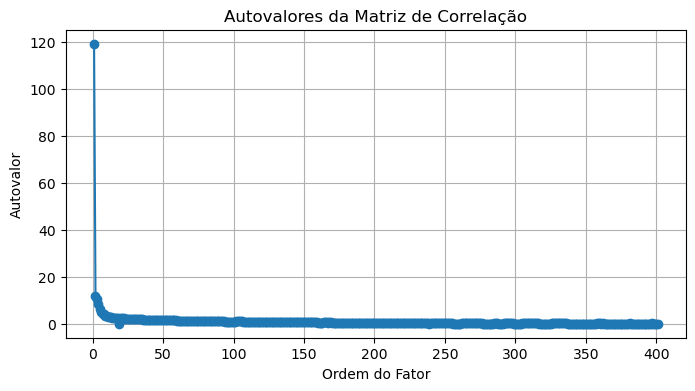

In [23]:
# PCA sobre matriz de correlação empírica
eigen_val,eigen_vec = np.linalg.eig(corr_matrix)
eigen_val_full,eigen_vec_full = np.linalg.eig(corr_matrix_full)
eigen_val = list(eigen_val)
eigen_vec = list(eigen_vec)
eigen_val_full = list(eigen_val_full)
eigen_vec_full = list(eigen_vec_full)

display(eigen_val[:20])

# plotando os autovalores
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(eigen_val)+1), eigen_val, 'o-')
plt.title("Autovalores da Matriz de Correlação")
plt.xlabel("Ordem do Fator")
plt.ylabel("Autovalor")
plt.grid(True)
plt.show()


(0.5, 25.0)

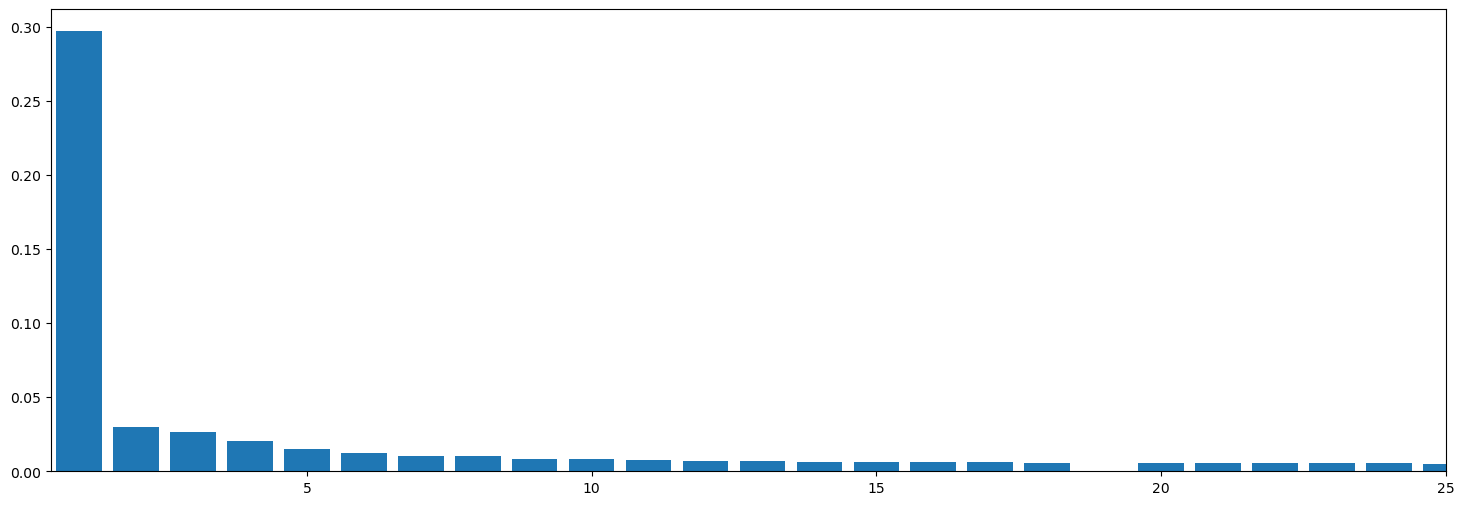

In [25]:
plt.figure(figsize=(18,6))
plt.bar(np.arange(1, len(eigen_val)+1),height = (eigen_val)/sum(eigen_val))
plt.xlim(0.5,25)
#plt.ylim(0,0.7)

In [27]:
eigen_vec[0]

array([ 4.98282876e-02,  2.18808653e-02,  5.21643258e-03,  1.71218576e-02,
       -1.61631480e-02, -2.98934224e-02, -1.54930083e-02,  2.06308262e-02,
       -9.16171394e-02, -2.21381774e-02,  8.43771652e-02,  5.58527170e-02,
        3.02016801e-03,  8.12800082e-04, -4.05183574e-02, -3.21652326e-02,
       -1.99067103e-02,  2.22727162e-02,  4.88052933e-07,  7.50641699e-02,
       -3.13363171e-02,  7.53584926e-02,  5.84815549e-02, -5.83737503e-02,
       -1.11885765e-02, -3.62438637e-03,  3.57606798e-02, -7.55901745e-02,
       -3.86961598e-02,  2.01789966e-02, -6.08436963e-02,  1.68164316e-02,
       -2.82488445e-03,  4.51203834e-03,  3.62172699e-02,  8.58650287e-02,
       -2.64820504e-02,  5.39053395e-02,  1.35343332e-02, -5.87915215e-03,
       -1.39770800e-01,  1.28515744e-02, -5.34435923e-03,  1.73702402e-01,
        5.47938663e-02, -1.11158974e-02, -2.50814230e-02, -3.34462199e-03,
       -4.26354803e-02,  4.04068408e-02, -3.07122460e-02, -2.02461208e-02,
       -2.30594977e-02, -

In [29]:
# Pesos do Eigenportifolio de mercado
weights = eigen_vec[0]/returns.std()
weights = weights/weights.sum()
weights_full = eigen_vec_full[0]/returns_full.std()
weights_full = weights_full/weights_full.sum()

# Pesos do 15º Eigenportifolio
weights2 = eigen_vec[14]/returns.std()
weights2 = weights2/weights2.sum()
weights2_full = eigen_vec_full[14]/returns_full.std()
weights2_full = weights2_full/weights2_full.sum()

weights

MMM     0.095779
AOS     0.022526
ABT     0.010254
ACN     0.024509
ADBE   -0.019856
          ...   
WYNN   -0.000358
XEL     0.007277
YUM    -0.018533
ZBRA   -0.001122
ZBH     0.001519
Length: 401, dtype: float64

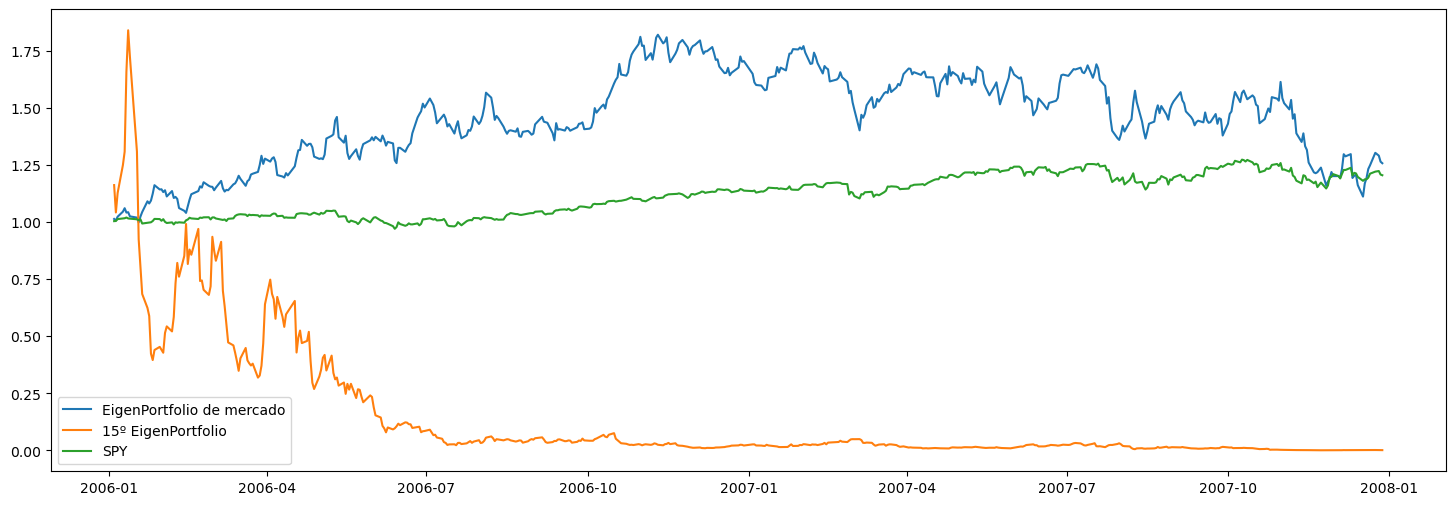

In [35]:
ret_eig = np.cumprod((weights*returns).sum(axis=1)+1)
ret_eig2 = np.cumprod((weights2*returns).sum(axis=1)+1)
ret_spy = np.cumprod((returns_spy).sum(axis=1)+1)

plt.figure(figsize=(18,6))
plt.plot(ret_eig,label='EigenPortfolio de mercado')
plt.plot(ret_eig2,label='15º EigenPortfolio')
plt.plot(ret_spy,label = 'SPY')

plt.legend()

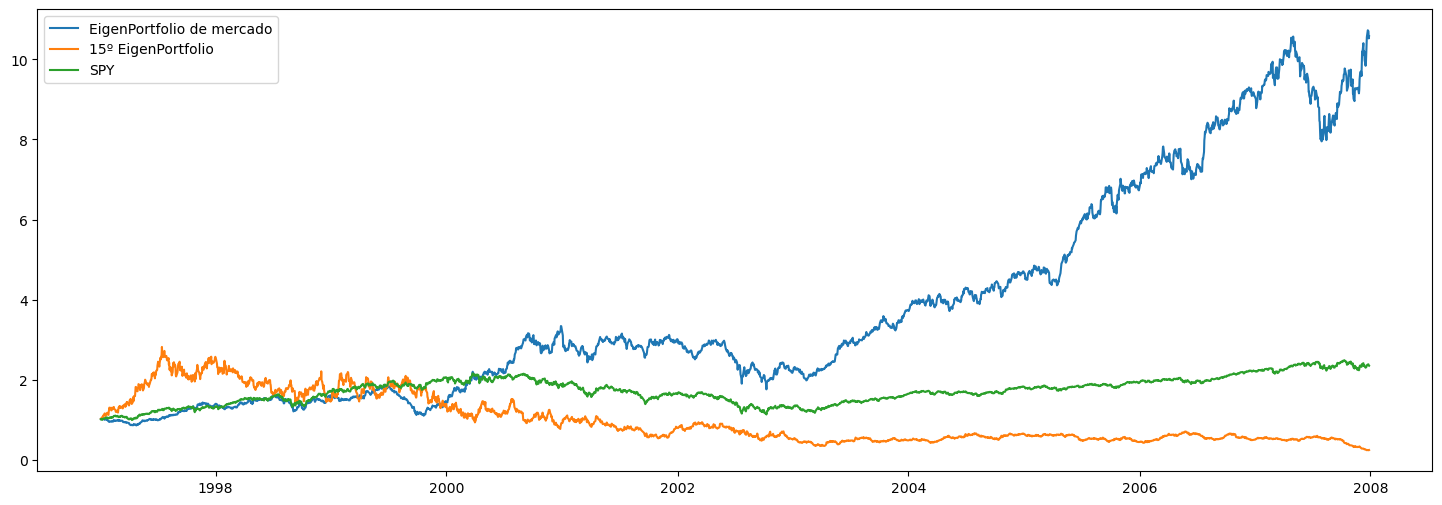

In [33]:
ret_eig_full = np.cumprod((weights_full*returns_full).sum(axis=1)+1)
ret_eig2_full = np.cumprod((weights2_full*returns_full).sum(axis=1)+1)
ret_spy_full = np.cumprod((returns_spy_full).sum(axis=1)+1)

plt.figure(figsize=(18,6))
plt.plot(ret_eig_full,label='EigenPortfolio de mercado')
plt.plot(ret_eig2_full,label='15º EigenPortfolio')
plt.plot(ret_spy_full,label = 'SPY')

plt.legend()

Modelo contínuo com $m = 15 $ : $$
\frac{dS_i(t)}{S_i(t)} = \sum_{j=1}^m \beta_{ij} F_j(t) + dX_i(t)
$$

Esse modelo :

* Estima os betas de cada ativo com relação aos fatores

* Extrae os resíduos da regressão, que serão modelados como processo OU

* Calcula os parâmetros do OU: velocidade de reversão (κ), média de longo prazo (m), volatilidade (σ)

* Constroe sinais de reversão à média (s-score) com base nisso

In [13]:
data.head()

Ticker,AAPL,ALK,APA,BAC,CL,CSCO,DIS,DTE,ED,HD,...,PFE,PG,PNW,RRC,SLB,SO,T,TGT,VZ,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1997-01-02,0.157784,4.749223,10.761827,11.693560,6.305496,4.572003,16.693434,7.959299,7.739370,6.366409,...,5.018901,13.087708,9.159231,11.063407,13.116521,3.610240,3.255640,5.613114,8.087781,10.249756
1997-01-03,0.163419,4.777326,10.761827,11.843671,6.296835,4.771973,17.158005,7.928687,7.772872,6.447409,...,5.126178,13.302510,9.159231,11.136193,13.182106,3.610240,3.263375,5.558083,8.057606,10.275804
1997-01-06,0.134304,4.749223,10.761827,11.858683,6.383445,4.908312,17.096060,7.806240,7.772872,6.512206,...,5.103189,13.394575,9.159231,11.572902,13.854330,3.650805,3.247907,5.374649,8.027428,10.419066
1997-01-07,0.131487,4.833530,10.799201,11.873698,6.322819,4.962850,17.065083,7.898074,7.873383,6.658000,...,5.179814,13.640057,9.270027,12.591904,14.149451,3.711651,3.209241,5.594770,7.891624,10.445118
1997-01-08,0.132426,4.805428,10.986033,12.158902,6.348801,4.817419,16.844217,7.836846,8.007395,6.641804,...,5.179814,13.394575,9.159231,12.082403,14.116656,3.671087,3.190122,5.337961,7.765910,10.366969


In [85]:
# Função que estima os parâmetros do processo OU
def estimate_OU_parameters(residuals):
    X = np.cumsum(residuals)  # processo acumulado
    Xn = X[:-1].reshape(-1, 1)
    Xn1 = X[1:]

    reg = LinearRegression().fit(Xn, Xn1)
    a = reg.intercept_
    b = reg.coef_[0]
    zeta = Xn1 - reg.predict(Xn)
    var_zeta = np.var(zeta, ddof=1)

    # Checagem para evitar valores inválidos
    if b <= 0 or b >= 1:
        return None

    kappa = -np.log(b) * 252
    m = a / (1 - b)
    sigma = np.sqrt(var_zeta * 2 * kappa / (1 - b ** 2))
    sigma_eq = np.sqrt(var_zeta / (1 - b ** 2))
    s_score = -m / sigma_eq

    return {
        'kappa': kappa,
        'm': m,
        'sigma': sigma,
        'sigma_eq': sigma_eq,
        's_score': s_score,
        'b': b
    }

In [87]:
# Preparar fatores de PCA
# ------------------------

n_factors = 15  # número de fatores principais a usar
sigma = returns.std()  # desvio padrão dos ativos (Series N,)

# Normaliza os autovetores pelos desvios padrão dos ativos
eigen_matrix = np.array(eigen_vec[:n_factors])  # shape: (15, N)
norm_eigen_vecs = eigen_matrix / sigma.values  # shape: (15, N)

# Calcula os retornos dos fatores principais (eigenportfolios)
factors = returns @ norm_eigen_vecs.T  # shape: (datas, 15)
factors = pd.DataFrame(factors)
columns=[f'F{i+1}' for i in range(n_factors)]
factors.index = returns.index
factors.columns = columns

factors.head()

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15
Date,,,,,,,,,,,,,,,
2006-01-04,0.643095,1.896715,-2.962354,0.062744,0.177401,-0.717634,-0.110792,0.547853,-0.171760,-0.945880,0.059306,1.186137,-0.194689,0.514289,-0.950684
2006-01-05,-0.308168,-0.742445,-0.151887,1.267173,0.277745,0.671795,-0.171476,-0.782700,0.533281,-0.988238,-1.758847,0.185498,1.012376,1.463637,0.602841
2006-01-06,0.750720,0.957931,-1.942871,-0.338691,1.702661,-0.194739,-0.507272,0.981181,0.184556,0.124437,0.548529,0.772648,0.107805,-0.000099,-0.479791
2006-01-09,0.958248,-0.744099,-1.835717,-1.306143,1.192112,0.637486,0.029104,0.071799,0.413097,0.615457,0.472304,1.433744,-0.073446,0.308725,-0.631973
2006-01-10,0.652486,1.036699,0.888653,0.526450,-0.833915,0.582409,0.665035,0.307717,-0.697788,-0.277316,-1.112891,1.798567,0.074939,1.611133,-0.275545


In [89]:
betas = pd.DataFrame(index=returns.columns, columns=[f'Beta_{i+1}' for i in range(n_factors)])
ou_params = pd.DataFrame(columns=['kappa', 'm', 'sigma', 'sigma_eq', 's_score', 'b'])

display(betas.head())
ou_params

,Beta_1,Beta_2,Beta_3,Beta_4,Beta_5,Beta_6,Beta_7,Beta_8,Beta_9,Beta_10,Beta_11,Beta_12,Beta_13,Beta_14,Beta_15
MMM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ABT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ADBE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,kappa,m,sigma,sigma_eq,s_score,b


In [93]:
# Regressão + resíduos + OU para cada ação

# Loop principal por ticker
for ticker in returns.columns:
    try:
        y = returns[ticker].dropna()
        X = factors.loc[y.index]

        # Regressão do retorno da ação sobre os fatores
        reg = LinearRegression().fit(X, y)
        betas.loc[ticker] = reg.coef_

        # Resíduos
        residuals = y - reg.predict(X)

        # Estima parâmetros do processo OU
        ou_result = estimate_OU_parameters(residuals.values)
        if ou_result is not None:
            ou_params.loc[ticker] = ou_result
    except Exception as e:
        print(f"Erro em {ticker}: {e}")

# Limpeza final
ou_params = ou_params.dropna()

# ------------------------
# RESULTADOS
# ------------------------

# Salva os betas e parâmetros OU se quiser
# betas.to_csv("betas_pca.csv")
# ou_params.to_csv("ou_parameters.csv")

# Visualização básica
print("Resumo dos parâmetros OU:")
display(ou_params.describe())

print("\nExemplo de s-scores mais extremos (potenciais candidatos):")
display(ou_params.sort_values("s_score").head())
display(ou_params.sort_values("s_score").tail())

Resumo dos parâmetros OU:


,kappa,m,sigma,sigma_eq,s_score,b
count,401.000000,401.000000,401.000000,401.000000,401.000000,401.000000
mean,4.760095,0.005994,0.223508,0.081369,-0.121958,0.981338
std,2.565280,0.097633,0.083437,0.041438,1.040380,0.009917
min,0.607359,-0.382401,0.094168,0.024539,-2.546731,0.928830
25%,2.893027,-0.040270,0.165365,0.053103,-0.821590,0.976332
50%,4.185558,0.009971,0.201999,0.068975,-0.172896,0.983528
75%,6.036056,0.058276,0.257929,0.102707,0.656910,0.988585
max,18.605066,0.339903,0.602019,0.264999,2.347629,0.997593



Exemplo de s-scores mais extremos (potenciais candidatos):


,kappa,m,sigma,sigma_eq,s_score,b
MU,4.955549,0.244930,0.302775,0.096174,-2.546731,0.980527
CSCO,6.393735,0.150646,0.224238,0.062707,-2.402377,0.974947
LYV,5.864119,0.268516,0.383314,0.111928,-2.399009,0.976998
PCG,7.018264,0.089040,0.145210,0.038759,-2.297305,0.972534
OKE,5.094575,0.143531,0.201760,0.063207,-2.270803,0.979986


,kappa,m,sigma,sigma_eq,s_score,b
GOOGL,5.318300,-0.165331,0.251639,0.077157,2.142782,0.979117
PGR,7.106938,-0.110960,0.188364,0.049962,2.220889,0.972192
AAPL,4.015484,-0.261924,0.331688,0.117043,2.237848,0.984192
INCY,5.741161,-0.326539,0.485438,0.143258,2.279376,0.977475
INTC,3.845340,-0.168098,0.198571,0.071603,2.347629,0.984857


In [15]:
# data     → preços ajustados (df com índice = datas, colunas = tickers)
# factors  → retornos dos fatores principais (df com índice = componentes, colunas = datas)

# 1. Calcular os retornos logarítmicos das ações
returns = np.log(data / data.shift(1)).dropna()

# 2. Transpor fatores e colocar datas como índice, em ordem crescente
factors_T = factors.T.sort_index()  # Agora índice = datas

# 3. Alinhar os dois DataFrames
common_dates = returns.index.intersection(factors_T.index)
R = returns.loc[common_dates]
F = factors_T.loc[common_dates]

# 4. Inicializar os DataFrames de betas e resíduos
m = F.shape[1]  # número de fatores principais
betas = pd.DataFrame(index=R.columns, columns=[f"F{j+1}" for j in range(m)], dtype=float)
residuals = pd.DataFrame(index=R.index, columns=R.columns, dtype=float)

betas.head()

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15
Ticker,,,,,,,,,,,,,,,
AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ALK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
APA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BAC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
residuals.head()

Ticker,AAPL,ALK,APA,BAC,CL,CSCO,DIS,DTE,ED,HD,...,PFE,PG,PNW,RRC,SLB,SO,T,TGT,VZ,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1997-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1997-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1997-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1997-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1997-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
# 5. Regressão para cada ação
for ticker in R.columns:
    y = R[ticker].values
    X = F.values
    model = LinearRegression().fit(X, y)
    betas.loc[ticker] = model.coef_
    residuals[ticker] = y - model.predict(X)

# Resultado:
print("Betas:")
display(betas.head())
print("\nResíduos:")
display(residuals.head())

Betas:


,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15
Ticker,,,,,,,,,,,,,,,
AAPL,-0.004851,0.007773,-0.001561,0.005319,-0.007373,0.001325,-0.006227,0.000774,0.012802,-0.014491,-0.013871,-0.009505,0.014775,0.003209,0.007090
ALK,-0.005125,0.002568,0.001318,0.001684,0.009411,0.001930,0.003815,-0.001080,-0.011099,-0.005405,-0.008372,-0.008319,-0.001412,-0.014861,-0.006747
APA,-0.003027,-0.002186,-0.011995,-0.004931,-0.000563,-0.000429,-0.000397,0.002035,0.000919,0.002588,-0.000549,-0.002025,-0.000076,-0.002457,0.001105
BAC,-0.004455,0.001498,0.001589,-0.000373,0.004226,0.000583,-0.007473,-0.007456,0.002237,0.005643,-0.002444,0.002701,0.000228,0.000539,-0.000564
CL,-0.003086,-0.001154,0.004014,-0.005116,-0.002876,0.003454,-0.004348,0.003959,-0.003350,0.001126,-0.003092,0.000760,0.000750,-0.000261,0.002750



Resíduos:


Ticker,AAPL,ALK,APA,BAC,CL,CSCO,DIS,DTE,ED,HD,...,PFE,PG,PNW,RRC,SLB,SO,T,TGT,VZ,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1997-01-03,0.001497,-0.002190,0.002406,0.006404,-0.009727,-0.003232,0.003177,-0.002604,0.002881,0.010984,...,0.004526,0.008057,0.001224,0.001091,0.000880,-0.001505,0.005138,-0.011173,-0.003176,-0.003059
1997-01-06,-0.031602,0.000389,-0.027838,0.000891,0.007218,0.033618,-0.000824,-0.011740,0.002520,0.021108,...,-0.012774,0.000722,-0.002760,0.014330,0.019686,0.015149,-0.001331,-0.019476,0.001159,0.007690
1997-01-07,0.000857,-0.002363,-0.007567,0.002549,-0.013289,0.010724,0.003241,0.000518,-0.001108,-0.005775,...,0.005829,0.013069,-0.000138,-0.000716,0.015122,0.003222,0.001723,0.002480,-0.001927,-0.004171
1997-01-08,0.012591,0.006594,0.012477,0.005162,0.007362,-0.020303,-0.002350,-0.005833,0.019125,0.016895,...,-0.000881,-0.015198,-0.010756,-0.006995,-0.008658,-0.009916,0.007925,-0.015658,-0.003080,-0.004427
1997-01-09,0.001560,0.008866,-0.000906,0.000664,-0.003431,0.010252,-0.003339,-0.007496,0.003542,-0.014457,...,-0.010462,0.000841,0.000408,-0.000944,-0.011799,0.000226,-0.006356,0.015597,0.004907,0.012859


In [18]:
# --- CONFIGURAÇÕES ---
window = 60  # janela de 60 dias
delta_t = 1 / 252  # passo diário (anos)

# Inicializar lista de resultados
ou_results = []

# Iterar por ação
for ticker in residuals.columns:
    series = residuals[ticker].dropna()
    
    # Verificar se tem dados suficientes
    if len(series) < window:
        continue
    
    # Selecionar janela mais recente
    eps = series.iloc[-window:].values  # resíduos: ε₁, ..., ε₆₀

    # Construir processo auxiliar Xₖ = ∑ εⱼ
    X = np.cumsum(eps)

    # Xₙ vs Xₙ₊₁ para n = 1,...,59
    Xn = X[:-1]
    Xn1 = X[1:]

    # Estimar a e b via regressão linear
    reg = LinearRegression().fit(Xn.reshape(-1, 1), Xn1)
    a = reg.intercept_
    b = reg.coef_[0]

    # Verificar restrição 0 < b < 0.9672
    if b <= 0 or b >= 0.9672:
        continue

    # Estimar variância do ruído ζₙ₊₁
    zeta = Xn1 - reg.predict(Xn.reshape(-1, 1))
    var_zeta = np.var(zeta, ddof=1)

    # Estimar parâmetros OU
    kappa = -np.log(b) * 252
    m = a / (1 - b)
    sigma = np.sqrt((var_zeta * 2 * kappa) / (1 - b**2))
    sigma_eq = np.sqrt(var_zeta / (1 - b**2))
    s_score = -m / sigma_eq  # será ajustado com média centrada depois

    ou_results.append({
        "Stock": ticker,
        "a": a,
        "b": b,
        "kappa": kappa,
        "m": m,
        "sigma": sigma,
        "sigma_eq": sigma_eq,
        "s_score": s_score
    })

# Converter para DataFrame
ou_df = pd.DataFrame(ou_results)

# --- Correção para média centrada no s-score (fórmula 22) ---
mean_m = ou_df["m"].mean()
ou_df["s_score"] = -ou_df["m"] / ou_df["sigma_eq"] + mean_m / ou_df["sigma_eq"]

# Exibir resultados
ou_df.head()

,Stock,a,b,kappa,m,sigma,sigma_eq,s_score
0,AAPL,-0.001896,0.920905,20.764386,-0.023969,0.099802,0.015487,1.921854
1,ALK,-0.002633,0.942540,14.912499,-0.045830,0.075061,0.013744,3.756039
2,APA,0.006366,0.942570,14.904498,0.110842,0.161378,0.029558,-3.553984
3,CL,0.003783,0.937141,16.360235,0.060182,0.091230,0.015949,-3.410160
4,CSCO,-0.004518,0.926862,19.139537,-0.061774,0.241288,0.038999,1.732563


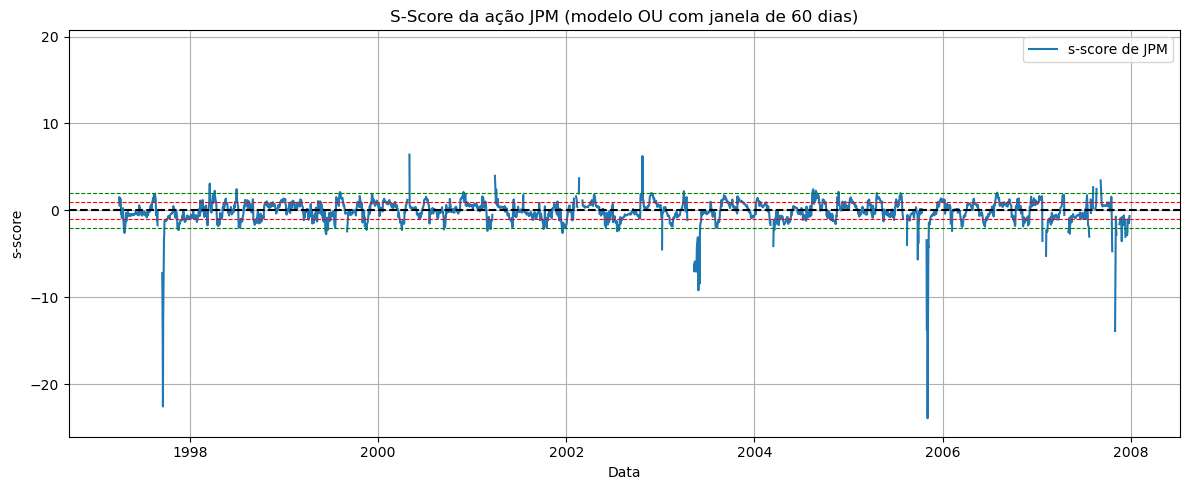

In [19]:
# Plotar s-score para a ação JPM

# Parâmetros
window = 60  # janela de 60 dias
ticker = "JPM"  # ação de interesse

# Série temporal do resíduo da ação
X_series = residuals[ticker]

# Inicializar listas para armazenar os s-scores
s_scores = []

# Iterar sobre janelas móveis
for i in range(len(X_series) - window):
    window_residuals = X_series[i:i+window].values

    # Ignorar janelas com NaN
    if np.isnan(window_residuals).any():
        s_scores.append(np.nan)
        continue

    Xk = np.cumsum(window_residuals)

    # Impor X_60 = 0 (último valor da janela)
    Xk = Xk - Xk[-1]

    # Ajustar modelo AR(1): X_{n+1} = a + b X_n + noise
    Xn = Xk[:-1].reshape(-1, 1)
    Xn1 = Xk[1:]
    reg = LinearRegression().fit(Xn, Xn1)
    a = reg.intercept_
    b = reg.coef_[0]
    residuals_ar1 = Xn1 - reg.predict(Xn)
    var_zeta = np.var(residuals_ar1, ddof=1)

    # Verificações de estabilidade
    if 0 < b < 0.9999 and var_zeta > 0:
        kappa = -np.log(b) * 252
        m = a / (1 - b)
        sigma_eq = np.sqrt(var_zeta / (1 - b**2))
        s = -m / sigma_eq
        s_scores.append(s)
    else:
        # print(f"[janela {i}] b = {b:.4f}, var_zeta = {var_zeta:.2e} → ignorado")
        s_scores.append(np.nan)

# Criar DataFrame com s-scores e datas
s_score_series = pd.Series(s_scores, index=X_series.index[window:])

# Plotar o s-score
plt.figure(figsize=(12, 5))
plt.plot(s_score_series, label=f"s-score de {ticker}")
plt.axhline(0, color='black', linestyle='--')
plt.axhline(1, color='red', linestyle='--', linewidth=0.8)
plt.axhline(-1, color='red', linestyle='--', linewidth=0.8)
plt.axhline(2, color='green', linestyle='--', linewidth=0.8)
plt.axhline(-2, color='green', linestyle='--', linewidth=0.8)
plt.title(f"S-Score da ação {ticker} (modelo OU com janela de {window} dias)")
plt.xlabel("Data")
plt.ylabel("s-score")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

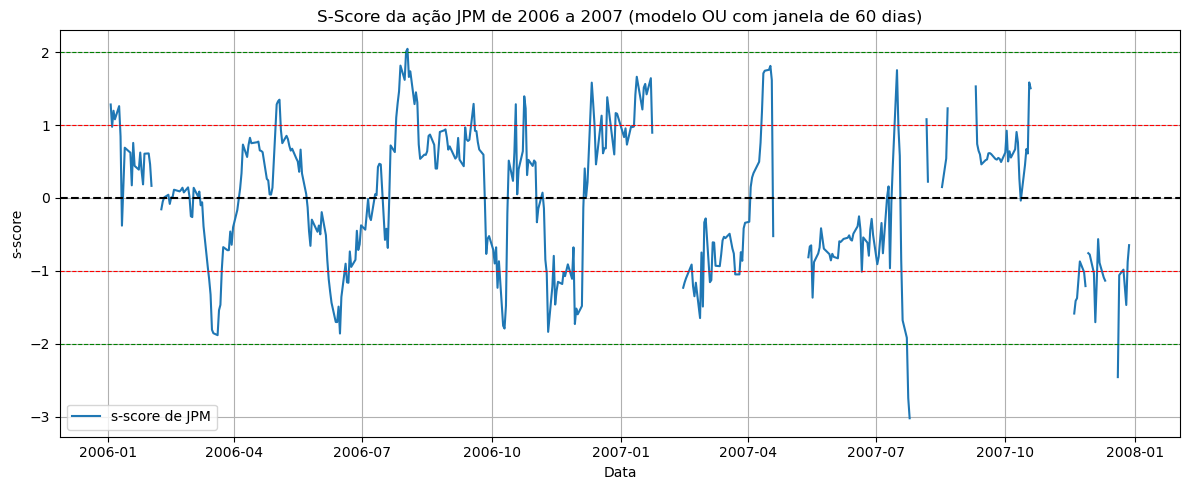

In [20]:
# Parâmetros
window = 60  # janela de 60 dias
ticker = "JPM"  # ação de interesse

# Série temporal do resíduo da ação
X_series = residuals[ticker]

# Inicializar listas para armazenar os s-scores e as datas correspondentes
s_scores = []
dates = []

# Iterar sobre janelas móveis
for i in range(len(X_series) - window):
    window_residuals = X_series[i:i + window].values
    Xk = np.cumsum(window_residuals)

    # Impor X_60 = 0 (último valor)
    Xk = Xk - Xk[-1]

    # Ajustar modelo AR(1): X_{n+1} = a + b X_n + noise
    Xn = Xk[:-1].reshape(-1, 1)
    Xn1 = Xk[1:]
    reg = LinearRegression().fit(Xn, Xn1)
    a = reg.intercept_    # Correção: é escalar
    b = reg.coef_[0]      # Correção: é escalar

    # Verificar se b está em uma faixa aceitável
    if b <= 0 or b >= 0.99:
        s_scores.append(np.nan)
    else:
        residuals_ar1 = Xn1 - reg.predict(Xn)
        var_zeta = np.var(residuals_ar1, ddof=1)

        # Estimar sigma_eq e s-score
        sigma_eq = np.sqrt(var_zeta / (1 - b ** 2))
        m = a / (1 - b)
        s = -m / sigma_eq
        s_scores.append(s)

    # Guardar a data final da janela
    dates.append(X_series.index[i + window])

# Criar DataFrame com s-scores e datas
s_score_series = pd.Series(s_scores, index=dates)

# Filtrar para o período de 2006 a 2007
s_score_filtered = s_score_series["2006-01-01":"2007-12-31"]

# Plotar o s-score
plt.figure(figsize=(12, 5))
plt.plot(s_score_filtered, label=f"s-score de {ticker}")
plt.axhline(0, color='black', linestyle='--')
plt.axhline(1, color='red', linestyle='--', linewidth=0.8)
plt.axhline(-1, color='red', linestyle='--', linewidth=0.8)
plt.axhline(2, color='green', linestyle='--', linewidth=0.8)
plt.axhline(-2, color='green', linestyle='--', linewidth=0.8)
plt.title(f"S-Score da ação {ticker} de 2006 a 2007 (modelo OU com janela de {window} dias)")
plt.xlabel("Data")
plt.ylabel("s-score")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [61]:
# Construindo o DataFrame que contém os s-scores de todas as ações ao longo do tempo
from sklearn.linear_model import LinearRegression

window = 60
s_scores_df = pd.DataFrame(index=residuals.index[window:], columns=residuals.columns)

for ticker in residuals.columns:
    series = residuals[ticker].dropna()
    if len(series) < window:
        continue

    for i in range(len(series) - window):
        eps_window = series.iloc[i:i+window].values
        Xk = np.cumsum(eps_window)
        Xk = Xk - Xk[-1]  # forçar X_60 = 0

        Xn = Xk[:-1].reshape(-1, 1)
        Xn1 = Xk[1:]

        reg = LinearRegression().fit(Xn, Xn1)
        a = reg.intercept_
        b = reg.coef_[0]

        if b <= 0 or b >= 0.99:
            s = np.nan
        else:
            residuals_ar1 = Xn1 - reg.predict(Xn)
            var_zeta = np.var(residuals_ar1, ddof=1)
            sigma_eq = np.sqrt(var_zeta / (1 - b ** 2))
            m = a / (1 - b)
            s = -m / sigma_eq

        date = series.index[i + window]
        s_scores_df.at[date, ticker] = s

In [62]:
s_scores_df.head()

Ticker,AAPL,ALK,APA,BAC,CL,CSCO,DIS,DTE,ED,HD,...,PFE,PG,PNW,RRC,SLB,SO,T,TGT,VZ,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1997-04-01,0.037031,1.416822,-1.393086,-0.049989,-0.181124,2.017537,-1.210066,1.101174,0.770816,-1.360386,...,0.312819,-0.345374,0.106929,1.087616,-2.026766,0.641973,-0.787282,1.43079,0.282123,NaN
1997-04-02,-0.250045,0.962859,-0.992247,-0.505396,0.291143,1.25777,-1.752642,1.901838,0.34054,-1.349458,...,-0.472528,-0.372718,0.383983,1.399661,-0.460653,1.437132,-1.286382,1.592462,NaN,1.249996
1997-04-03,-0.216413,0.630183,-1.007784,0.090791,1.071015,1.126512,-1.516363,1.228498,-0.158891,-1.088928,...,-0.377627,-0.947743,0.649758,1.110099,-0.560735,1.689155,NaN,1.459987,NaN,1.219919
1997-04-04,-0.280397,0.046647,-0.82608,-0.496796,0.877044,1.317909,-1.01681,1.137127,-0.042783,-1.657881,...,-0.095885,-0.603438,0.703179,1.24045,0.349112,1.323816,-0.784642,1.867185,-0.076391,1.13708
1997-04-07,-0.139351,1.157958,-0.762535,-0.162256,-0.379532,0.993711,-0.20623,0.828857,-0.639006,-1.293355,...,0.46039,-0.401193,0.224689,0.638542,-0.548293,1.855578,-0.488348,1.34965,-0.302618,1.120044


In [68]:
# --------------------- PARÂMETROS DA ESTRATÉGIA ---------------------
threshold_open = 1.25
threshold_close = 0.5
slippage = 0.001  # 10 bps
leverage = 2.0
initial_equity = 100.0
delta_t = 1 / 252

# ALINHANDO DATAS
common_dates = returns.index.intersection(s_scores_df.index)

# Reindexar os dois DataFrames
returns = returns.loc[common_dates]
s_scores_df = s_scores_df.loc[common_dates]
dates = common_dates

# --------------------- INICIALIZAÇÃO ---------------------
tickers = returns.columns
positions = pd.DataFrame(0.0, index=dates, columns=tickers, dtype=float)
equity = [initial_equity]
pnl = []

# --------------------- LOOP NO TEMPO ---------------------
for t in range(len(dates) - 1):
    date = dates[t]
    next_date = dates[t + 1]
    current_equity = equity[-1]

    # S-scores e posições do dia atual
    s_today = s_scores_df.loc[date]
    pos_prev = positions.loc[date].copy()

    # Sinais de entrada e saída
    long_signal = (s_today < -threshold_open)
    short_signal = (s_today > threshold_open)
    close_signal = (s_today.abs() < threshold_close)

    # Atualizar posições
    pos_new = pos_prev.copy()
    pos_new[close_signal] = 0
    pos_new[long_signal] = 1
    pos_new[short_signal] = -1

    # Normalizar posições
    if pos_new.abs().sum() != 0:
        pos_scaled = leverage * pos_new / pos_new.abs().sum()
    else:
        pos_scaled = pos_new.copy()

    # Atualizar posições para o próximo dia
    positions.loc[next_date] = pos_scaled

    # Calcular PnL bruto
    ret = returns.loc[next_date]
    daily_pnl = (pos_scaled * ret).sum() * current_equity

    # Slippage (custo de rebalanceamento)
    trade_cost = slippage * (pos_scaled - pos_prev).abs().sum() * current_equity

    # Atualizar equity e PnL
    new_equity = current_equity + daily_pnl - trade_cost
    equity.append(new_equity)
    pnl.append(daily_pnl - trade_cost)

# --------------------- RESULTADOS FINAIS ---------------------
pnl_df = pd.Series(pnl, index=dates[1:], name="Daily_PnL")
equity_df = pd.Series(equity[1:], index=dates[1:], name="Equity")
positions = positions.loc[dates[1:]]

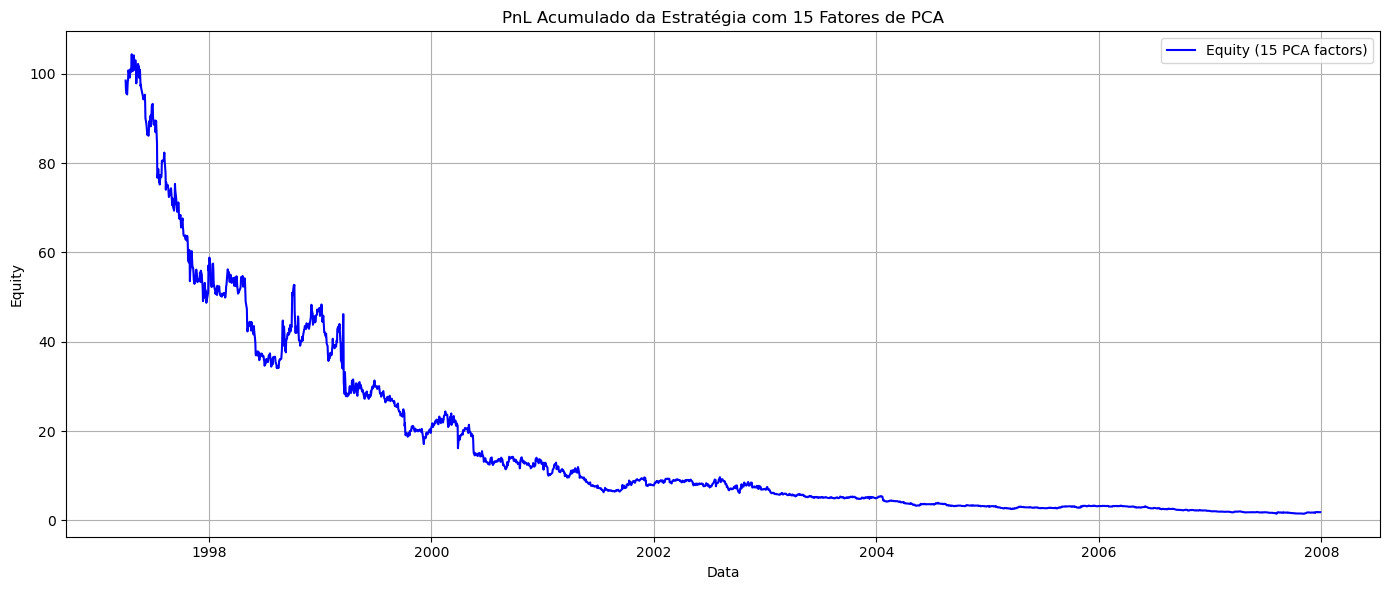

In [70]:
plt.figure(figsize=(14, 6))
plt.plot(equity_df.index, equity_df.values, label="Equity (15 PCA factors)", color="blue")
plt.title("PnL Acumulado da Estratégia com 15 Fatores de PCA")
plt.xlabel("Data")
plt.ylabel("Equity")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

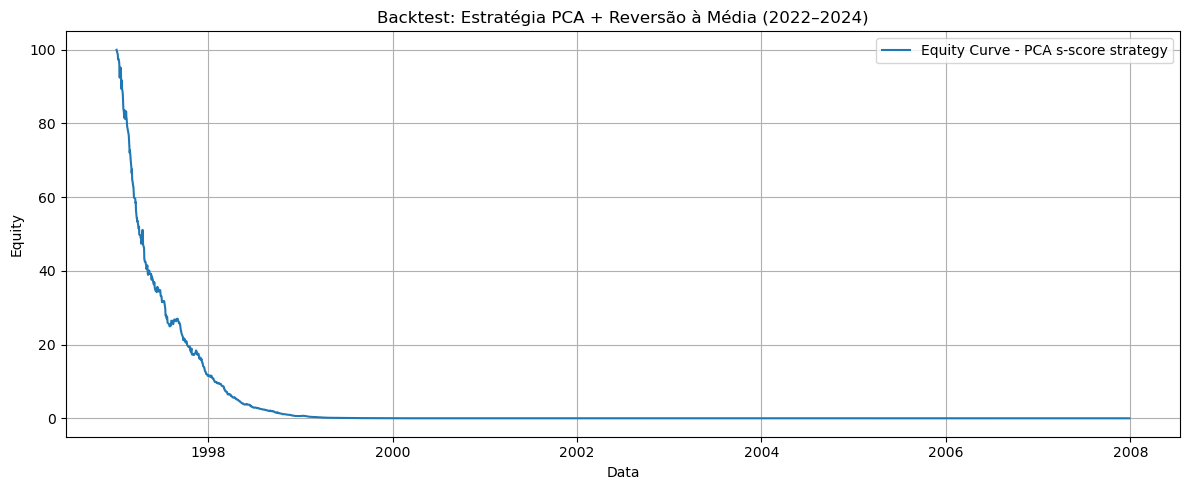

In [128]:
# Plot do resultado
plt.figure(figsize=(12, 5))
plt.plot(equity_curve, label="Equity Curve - PCA s-score strategy")
plt.title("Backtest: Estratégia PCA + Reversão à Média (2022–2024)")
plt.xlabel("Data")
plt.ylabel("Equity")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()